# EDA — CMAPSS NASA Turbofan Degradation

Analyse exploratoire du dataset CMAPSS (4 sous-datasets FD001–FD004).
Objectif : justifier les choix de prétraitement (RUL cap=125, seuil faulty=30, top-5 features) pour **Gap 1**.

In [1]:
import sys
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sys.path.insert(0, "..")
from src.data.cmapss_loader import (
    CMAPSS_FAULTY_THRESHOLD,
    CMAPSS_RUL_CAP,
    DATA_DIR_DEFAULT,
    DOMAIN_ORDER,
    SENSOR_NAMES,
    _load_raw,
    compute_feature_selection,
)

DATA_DIR = pathlib.Path("../data/raw/CMAPSS Jet Engine Simulated Data/")
FIGURES_DIR = pathlib.Path("figures/eda/cmapss")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("Setup OK")

Setup OK


## 1. Distribution RUL brut vs cappé (FD001)

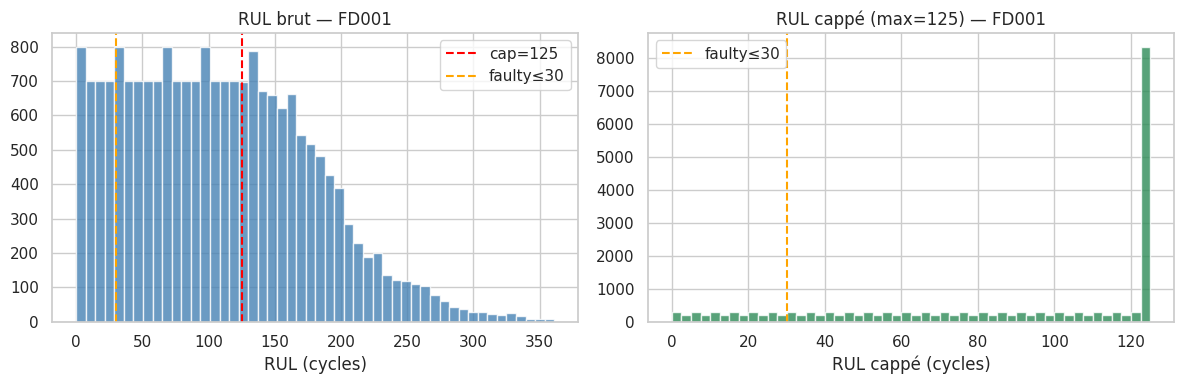

Taux faulty FD001 : 0.150


In [2]:
df_fd001 = _load_raw(DATA_DIR, "FD001")

# RUL brut (sans cap)
max_cycles = df_fd001.groupby("unit_nr")["time_cycles"].transform("max")
rul_raw = max_cycles - df_fd001["time_cycles"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rul_raw, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(CMAPSS_RUL_CAP, color="red", linestyle="--", label=f"cap={CMAPSS_RUL_CAP}")
axes[0].axvline(CMAPSS_FAULTY_THRESHOLD, color="orange", linestyle="--", label=f"faulty≤{CMAPSS_FAULTY_THRESHOLD}")
axes[0].set_title("RUL brut — FD001")
axes[0].set_xlabel("RUL (cycles)")
axes[0].legend()

axes[1].hist(df_fd001["RUL"], bins=50, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(CMAPSS_FAULTY_THRESHOLD, color="orange", linestyle="--", label=f"faulty≤{CMAPSS_FAULTY_THRESHOLD}")
axes[1].set_title(f"RUL cappé (max={CMAPSS_RUL_CAP}) — FD001")
axes[1].set_xlabel("RUL cappé (cycles)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "rul_distribution_fd001.png", dpi=120)
plt.show()
print(f"Taux faulty FD001 : {df_fd001['faulty'].mean():.3f}")

## 2. Drift domaine — distribution top-5 features × 4 sous-datasets

Top-5 features sélectionnées : ['Ps30', 'T50', 'Phi', 'P30', 'BPR']


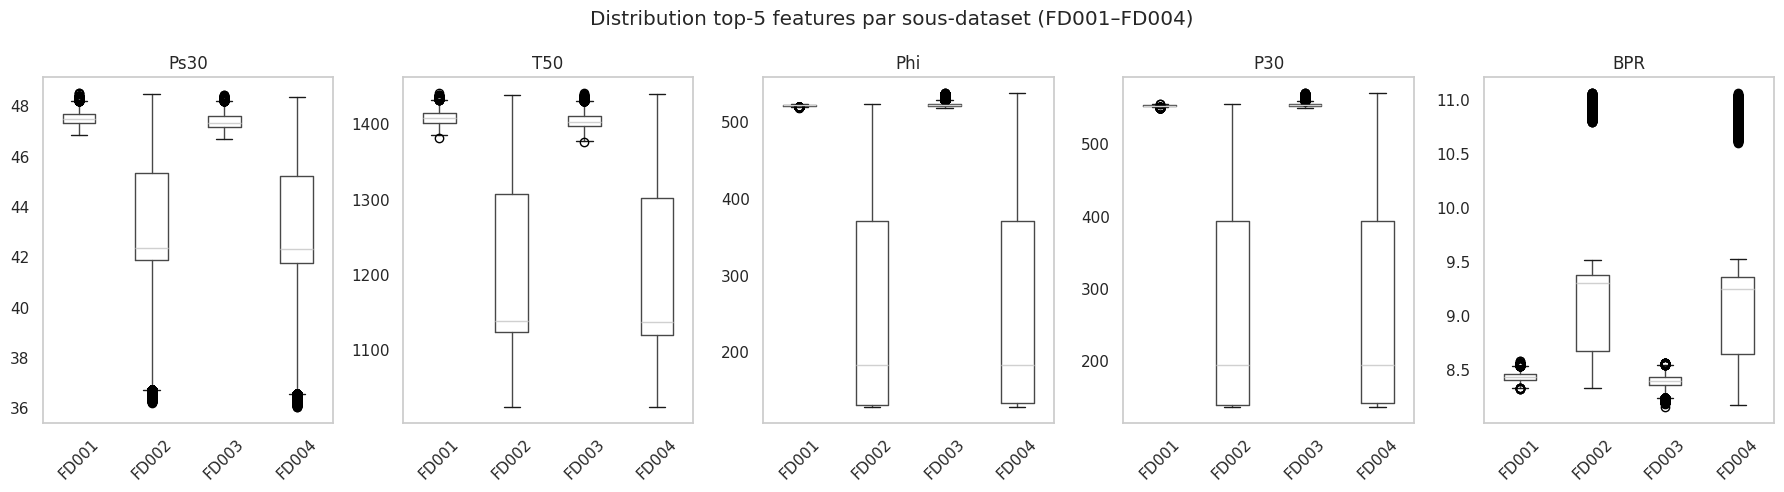

In [3]:
# Charger les 4 sous-datasets
dfs = {}
for domain in DOMAIN_ORDER:
    df_d = _load_raw(DATA_DIR, domain)
    df_d["domain"] = domain
    dfs[domain] = df_d

df_all = pd.concat(dfs.values(), ignore_index=True)

# Charger ou calculer les top-5 features
top5 = compute_feature_selection(DATA_DIR, n_features=5)
print(f"Top-5 features sélectionnées : {top5}")

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, feat in zip(axes, top5):
    df_all.boxplot(column=feat, by="domain", ax=ax, grid=False)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Distribution top-5 features par sous-dataset (FD001–FD004)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_drift_boxplot.png", dpi=120)
plt.show()

## 3. Matrice de corrélation — 21 capteurs × RUL

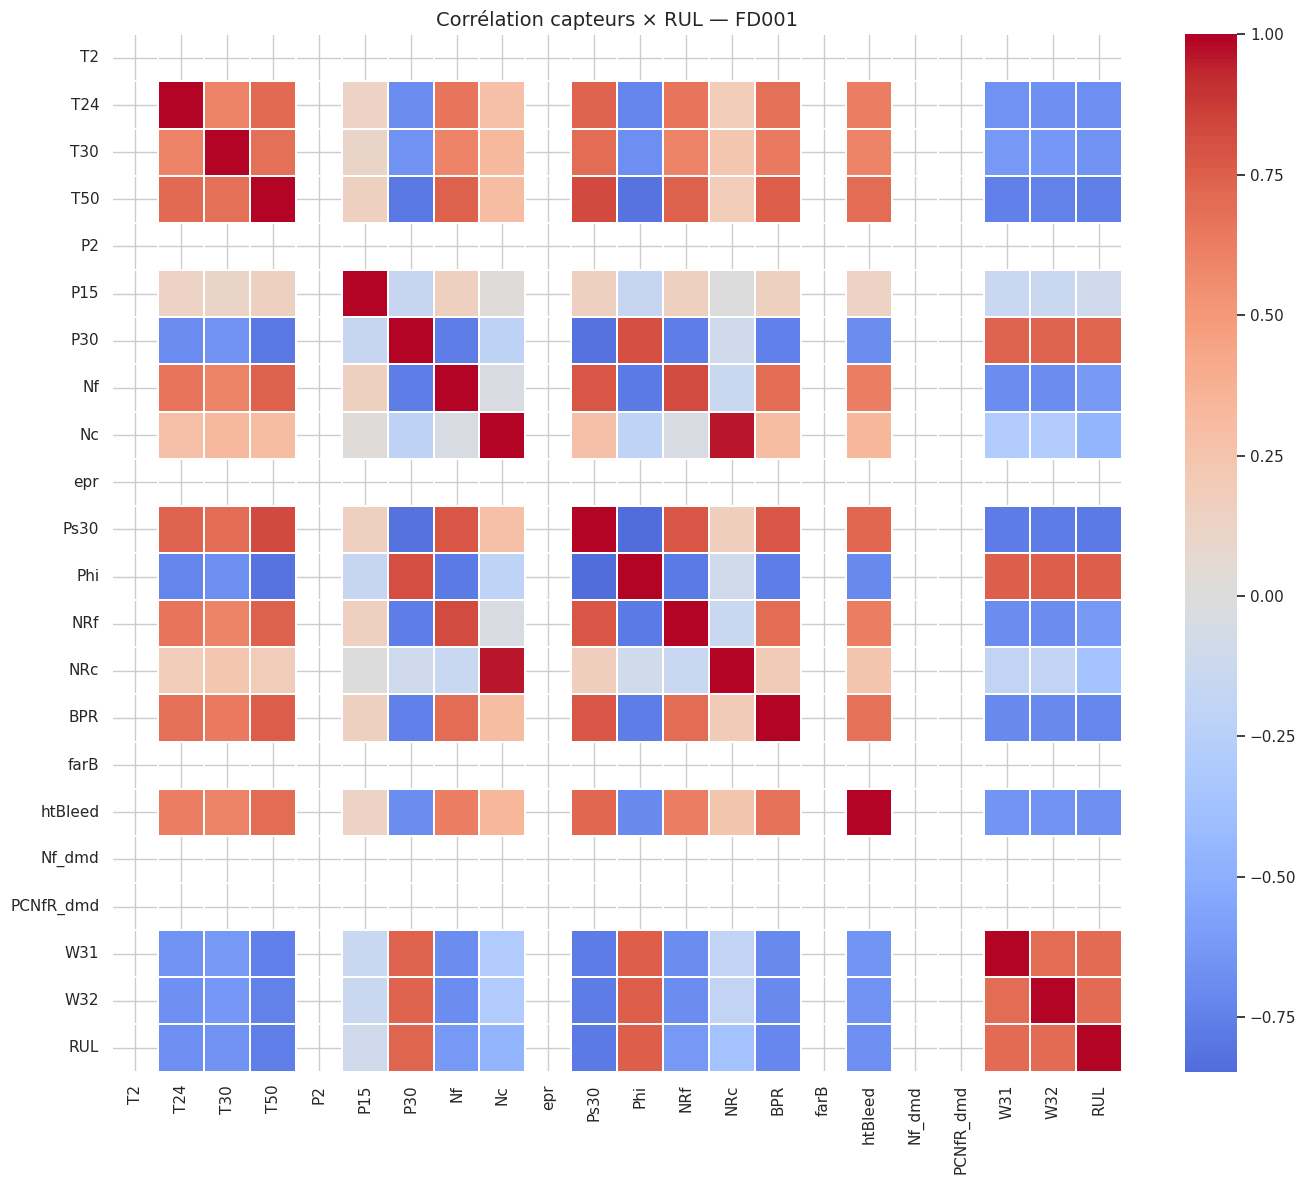

In [4]:
corr_cols = SENSOR_NAMES + ["RUL"]
corr_matrix = df_fd001[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.3,
)
ax.set_title("Corrélation capteurs × RUL — FD001", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap_fd001.png", dpi=120)
plt.show()

## 4. Ranking mutual info — top-5 vs bottom-5

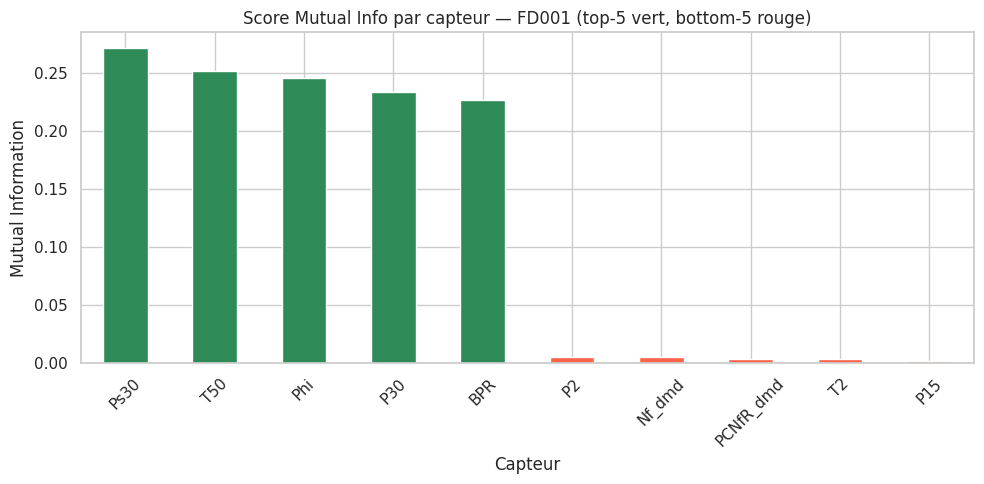

Top-5 : ['Ps30', 'T50', 'Phi', 'P30', 'BPR']
Bottom-5 : ['P2', 'Nf_dmd', 'PCNfR_dmd', 'T2', 'P15']


In [5]:
X_fd001 = df_fd001[SENSOR_NAMES].to_numpy(dtype=np.float32)
y_fd001 = df_fd001["faulty"].to_numpy()

mi_scores = mutual_info_classif(X_fd001, y_fd001, random_state=42)
mi_series = pd.Series(mi_scores, index=SENSOR_NAMES).sort_values(ascending=False)

top5_names = mi_series.head(5)
bottom5_names = mi_series.tail(5)
to_plot = pd.concat([top5_names, bottom5_names])

colors = ["seagreen"] * 5 + ["tomato"] * 5

fig, ax = plt.subplots(figsize=(10, 5))
to_plot.plot(kind="bar", color=colors, ax=ax, edgecolor="white")
ax.set_title("Score Mutual Info par capteur — FD001 (top-5 vert, bottom-5 rouge)")
ax.set_ylabel("Mutual Information")
ax.set_xlabel("Capteur")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mutual_info_ranking.png", dpi=120)
plt.show()

print("Top-5 :", list(top5_names.index))
print("Bottom-5 :", list(bottom5_names.index))

## 5. Taux de défaut par sous-dataset après binarisation

'domain  n_total  n_normal  n_faulty  faulty_rate\n FD001    20631     17531      3100     0.150259\n FD002    53759     45699      8060     0.149928\n FD003    24720     21620      3100     0.125405\n FD004    61249     53530      7719     0.126027'

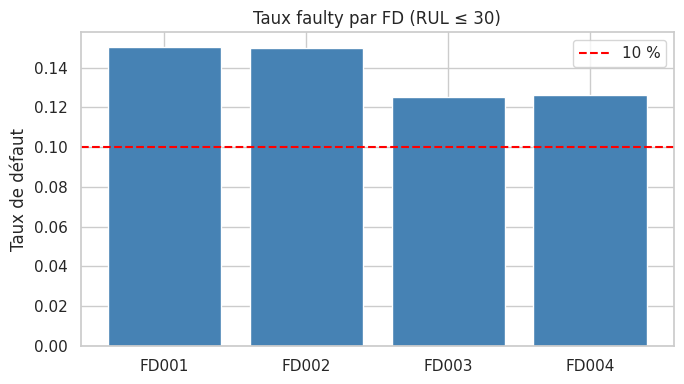

In [6]:
faulty_stats = []
for domain in DOMAIN_ORDER:
    df_d = _load_raw(DATA_DIR, domain)
    n_total = len(df_d)
    n_faulty = df_d["faulty"].sum()
    n_normal = n_total - n_faulty
    faulty_stats.append({
        "domain": domain,
        "n_total": n_total,
        "n_normal": n_normal,
        "n_faulty": n_faulty,
        "faulty_rate": n_faulty / n_total,
    })

df_stats = pd.DataFrame(faulty_stats)
display(df_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_stats["domain"], df_stats["faulty_rate"], color="steelblue", edgecolor="white")
ax.axhline(0.1, color="red", linestyle="--", label="10 %")
ax.set_ylabel("Taux de défaut")
ax.set_title(f"Taux faulty par FD (RUL ≤ {CMAPSS_FAULTY_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "faulty_rate_per_fd.png", dpi=120)
plt.show()

## 6. Trajectoires de dégradation RUL & capteurs (FD001)

CMAPSS est un dataset *run-to-failure* : chaque unité (`unit_nr`) est suivie cycle par cycle jusqu'à la panne. À gauche, le RUL décroît linéairement (montre l'horizon de défaillance) ; à droite, l'évolution de quelques capteurs top-5 au fil des cycles révèle la dérive physique exploitée pour la prédiction.

In [ ]:
# Trajectoires de dégradation : RUL et capteurs top-5 pour quelques unités FD001
top5 = compute_feature_selection(DATA_DIR, n_features=5)
unit_ids = sorted(df_fd001["unit_nr"].unique())
sel_units = unit_ids[:: max(1, len(unit_ids) // 5)][:5]
sensors_to_show = top5[:3]

fig, axes = plt.subplots(1, 1 + len(sensors_to_show), figsize=(5 * (1 + len(sensors_to_show)), 4))

for u in sel_units:
    dfu = df_fd001[df_fd001["unit_nr"] == u].sort_values("time_cycles")
    rul_u = dfu["time_cycles"].max() - dfu["time_cycles"]
    axes[0].plot(dfu["time_cycles"], rul_u, label=f"unit {u}", alpha=0.8)
axes[0].axhline(CMAPSS_FAULTY_THRESHOLD, color="orange", linestyle="--", label=f"faulty≤{CMAPSS_FAULTY_THRESHOLD}")
axes[0].set_title("RUL vs cycle (run-to-failure)")
axes[0].set_xlabel("time_cycles"); axes[0].set_ylabel("RUL")
axes[0].legend(fontsize=8)

for ax, feat in zip(axes[1:], sensors_to_show):
    for u in sel_units:
        dfu = df_fd001[df_fd001["unit_nr"] == u].sort_values("time_cycles")
        ax.plot(dfu["time_cycles"], dfu[feat], alpha=0.8, label=f"unit {u}")
    ax.set_title(f"{feat} vs cycle")
    ax.set_xlabel("time_cycles")

plt.suptitle("Trajectoires de dégradation — FD001 (5 unités représentatives)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rul_trajectories_fd001.png", dpi=120)
plt.show()

## 7. Tendance des features en fonction du RUL (FD001)

Pour chaque feature top-5, moyenne ± écart-type agrégés par tranche de RUL (bins de 10 cycles). Une dérive monotone à l'approche de la panne (RUL faible) confirme le **caractère discriminant** de la feature et justifie sa sélection. La ligne orange marque le seuil `faulty`.

In [ ]:
# Tendance des top-5 features en fonction du RUL (FD001) — moyenne ± std par tranche de RUL
rul_max = int(df_fd001["RUL"].max())
bins = np.arange(0, rul_max + 11, 10)
rul_bin = pd.cut(df_fd001["RUL"], bins=bins)
centers = [iv.mid for iv in rul_bin.cat.categories]

fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4), sharex=True)
for ax, feat in zip(axes, top5):
    grp = df_fd001.groupby(rul_bin, observed=True)[feat]
    mean = grp.mean()
    std = grp.std()
    ax.plot(centers, mean.values, marker="o", markersize=3, color="steelblue")
    ax.fill_between(
        centers, (mean - std).values, (mean + std).values, alpha=0.2, color="steelblue"
    )
    ax.axvline(CMAPSS_FAULTY_THRESHOLD, color="orange", linestyle="--")
    ax.set_title(feat)
    ax.set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Valeur (moyenne ± std)")

plt.suptitle("Tendance des top-5 features en fonction du RUL — FD001 (orange = seuil faulty)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_vs_rul_fd001.png", dpi=120)
plt.show()

## 8. Distribution des features par domaine et par label

Réutilise le helper `plot_violin_by_group_and_label` (`src/evaluation/eda_plots.py`). Chaque ligne = un sous-dataset (FD), chaque colonne = une feature top-5, les violons sont colorés par `faulty`. Permet de lire simultanément le **drift inter-domaine** et la **séparabilité normal/faulty**.

In [ ]:
from src.evaluation.eda_plots import plot_violin_by_group_and_label

# Grille (domaine × feature), violons colorés par label faulty
fig = plot_violin_by_group_and_label(
    df_all,
    top5,
    label_col="faulty",
    group_col="domain",
    label_name="Faulty",
    title="Top-5 features par sous-dataset et par label (FD001–FD004)",
)
fig.savefig(FIGURES_DIR / "feature_violin_domain_label.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Projection PCA 2D de l'espace features

Projection linéaire des top-5 features (standardisées) sur 2 composantes. À gauche, coloration par sous-dataset (FD) pour visualiser le **drift de domaine** ; à droite, coloration par label `faulty` pour juger la **séparabilité** des classes.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sous-échantillonnage équilibré par domaine (~2000 pts/FD)
sample_per_dom = 2000
parts = [
    g.sample(n=min(sample_per_dom, len(g)), random_state=42)
    for _, g in df_all.groupby("domain")
]
df_pca = pd.concat(parts, ignore_index=True)

X_std = StandardScaler().fit_transform(df_pca[top5].to_numpy(dtype=np.float32))
coords = PCA(n_components=2, random_state=42).fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for domain in DOMAIN_ORDER:
    m = df_pca["domain"].to_numpy() == domain
    axes[0].scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.5, label=domain)
axes[0].set_title("PCA top-5 — coloré par domaine FD")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

for lab, color, name in [(0, "#4CAF50", "Normal"), (1, "#F44336", "Faulty")]:
    m = df_pca["faulty"].to_numpy() == lab
    axes[1].scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.5, color=color, label=name)
axes[1].set_title("PCA top-5 — coloré par label")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend()

plt.suptitle("Projection PCA 2D de l'espace top-5 features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_domain_fd.png", dpi=120)
plt.show()

## 10. Dérive des corrélations par sous-dataset

La section 3 ne couvrait que FD001. Ici on compare les corrélations top-5 ↔ RUL pour les 4 sous-datasets : un changement de structure de corrélation entre FD confirme le **drift de domaine** (scénario domain-incremental).

In [ ]:
# Corrélations top-5 ↔ RUL par sous-dataset (dérive des relations inter-features entre domaines)
fig, axes = plt.subplots(1, len(DOMAIN_ORDER), figsize=(22, 5))
for ax, domain in zip(axes, DOMAIN_ORDER):
    corr = dfs[domain][top5 + ["RUL"]].corr()
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        cbar=False, ax=ax, linewidths=0.3, annot_kws={"size": 8},
    )
    ax.set_title(domain)

plt.suptitle("Corrélation top-5 ↔ RUL par sous-dataset (FD001–FD004)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_per_fd.png", dpi=120)
plt.show()

## 11. Justification du seuil RUL ≤ 30 et contribution Gap 1

In [7]:
# Justification Gap 1
print("CMAPSS contribue à Gap 1 : validation sur données industrielles réelles")
print("FD001→FD004 = conditions opératoires différentes (scénario domain-incremental)")
print("Binarisation RUL ≤ 30 : choix à valider avec Arnaud — voir TODO(arnaud)")

CMAPSS contribue à Gap 1 : validation sur données industrielles réelles
FD001→FD004 = conditions opératoires différentes (scénario domain-incremental)
Binarisation RUL ≤ 30 : choix à valider avec Arnaud — voir TODO(arnaud)


### Discussion du seuil RUL ≤ 30

**Justification domaine** : un seuil de 30 cycles restants correspond à une fenêtre de défaillance imminente
classiquement utilisée dans la littérature CMAPSS (cf. `Hurtado2023CLPdM`). Cette valeur représente environ
15–20 % de la durée de vie typique d'un moteur FD001 (~200 cycles).

**Alternatives** :
- RUL ≤ 15 : plus conservateur, taux de défaut plus faible (~5–8 %)
- RUL ≤ 50 : plus permissif, taux de défaut plus élevé (~25–35 %), risque de classe majoritaire

**TODO(arnaud)** : Valider le seuil RUL ≤ 30 comme critère de défaillance imminente.
**TODO(arnaud)** : Les capteurs constants dans FD001 (T2, P2, P15, epr, farB, Nf_dmd, PCNfR_dmd)
doivent-ils être exclus avant la sélection mutual info ?

' threshold  faulty_rate_fd001\n        15           0.077553\n        20           0.101789\n        25           0.126024\n        30           0.150259\n        40           0.198730\n        50           0.247201'

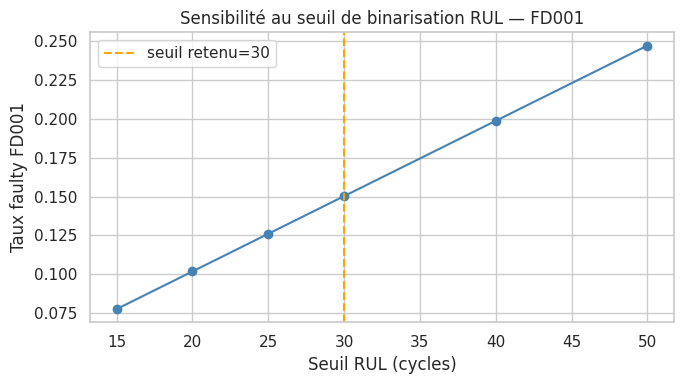

In [8]:
# Analyse de la sensibilité au seuil
thresholds = [15, 20, 25, 30, 40, 50]
results = []
for thresh in thresholds:
    rate = (df_fd001["RUL"] <= thresh).mean()
    results.append({"threshold": thresh, "faulty_rate_fd001": rate})

df_thresh = pd.DataFrame(results)
display(df_thresh.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_thresh["threshold"], df_thresh["faulty_rate_fd001"], marker="o", color="steelblue")
ax.axvline(CMAPSS_FAULTY_THRESHOLD, color="orange", linestyle="--", label=f"seuil retenu={CMAPSS_FAULTY_THRESHOLD}")
ax.set_xlabel("Seuil RUL (cycles)")
ax.set_ylabel("Taux faulty FD001")
ax.set_title("Sensibilité au seuil de binarisation RUL — FD001")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_sensitivity.png", dpi=120)
plt.show()